In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
admin1 = gpd.read_file(
    "../raw_data/Administrative boundaries/ssd_admin1.geojson"
)

admin2 = gpd.read_file(
    "../raw_data/Administrative boundaries/ssd_admin2.geojson"
)

print(admin1.shape)
print(admin2.shape)

print(admin2.columns)

(10, 22)
(79, 27)
Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',
       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',
       'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon',
       'geometry'],
      dtype='str')


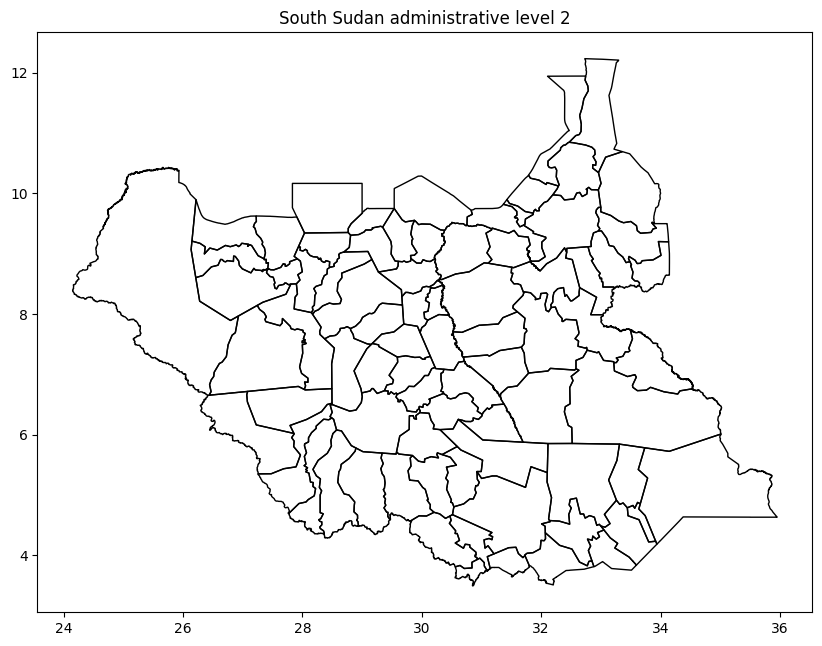

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))

admin2.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black"
)

plt.title("South Sudan administrative level 2")
plt.show()

In [4]:
flood_path = "../raw_data/flood_masks/compact_unusual/flood_events_h20v08_2020.parquet"

flood_2020 = pd.read_parquet(flood_path)

# Convert date to datetime
flood_2020["date"] = pd.to_datetime(flood_2020["date"])

print(flood_2020.shape)
print(flood_2020.columns)
print(flood_2020.dtypes)

(479356, 5)
Index(['date', 'lat', 'lon', 'tile', 'cloud_frac'], dtype='str')
date          category
lat            float32
lon            float32
tile          category
cloud_frac     float32
dtype: object


In [5]:
# Check the current type
print(flood_2020["date"].dtype)

# Convert categorical -> string -> datetime
flood_2020["date"] = pd.to_datetime(
    flood_2020["date"].astype(str)
)

print(flood_2020["date"].dtype)

category
datetime64[us]


In [6]:
print("Latitude:", flood_2020["lat"].min(), "to", flood_2020["lat"].max())
print("Longitude:", flood_2020["lon"].min(), "to", flood_2020["lon"].max())
print("Dates:", flood_2020["date"].min(), "to", flood_2020["date"].max())

Latitude: 0.0072916667 to 9.998959
Longitude: 20.001041 to 29.998959
Dates: 2020-01-01 00:00:00 to 2020-12-31 00:00:00


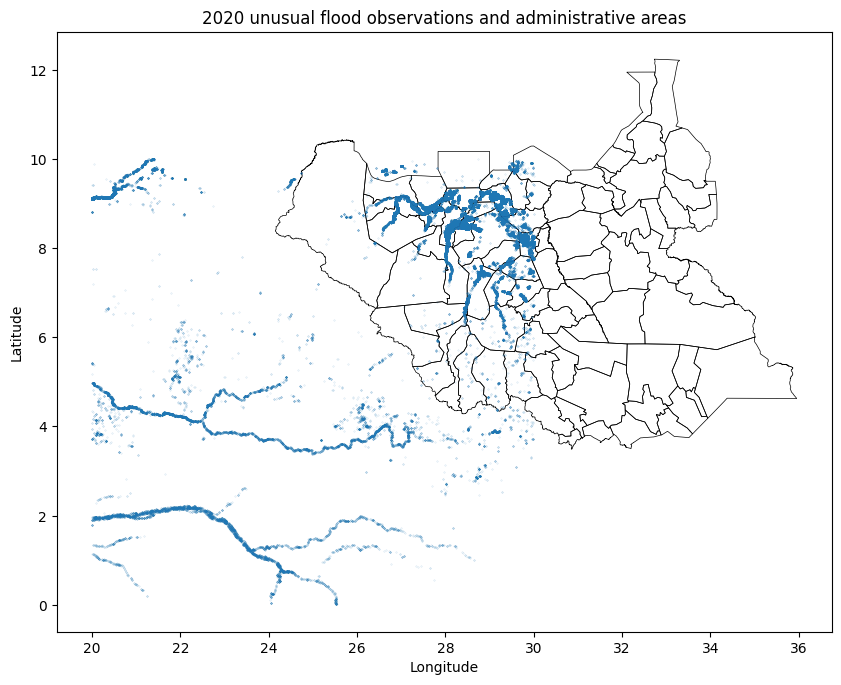

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

admin2.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
)

ax.scatter(
    flood_2020["lon"],
    flood_2020["lat"],
    s=0.05,
    alpha=0.3
)

ax.set_title("2020 unusual flood observations and administrative areas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [8]:
print("Number of observations:", len(flood_2020))

print("\nColumns:")
print(flood_2020.columns.tolist())

print("\nData types:")
print(flood_2020.dtypes)

print("\nDate range:")
print(flood_2020["date"].min(), "to", flood_2020["date"].max())

Number of observations: 479356

Columns:
['date', 'lat', 'lon', 'tile', 'cloud_frac']

Data types:
date          datetime64[us]
lat                  float32
lon                  float32
tile                category
cloud_frac           float32
dtype: object

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [9]:
import sys
sys.path.append("../processing_data")
from loading import load_flood_masks

In [10]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nDoes raw_data exist here?")
print((Path.cwd() / "raw_data").exists())

Current working directory:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\dashboard_notebooks

Does raw_data exist here?
False


In [11]:
import os
from pathlib import Path

original_cwd = Path.cwd()

# Move from dashboard_notebooks/ to the repository root
os.chdir("..")

print("Working directory for loading data:")
print(Path.cwd())

Working directory for loading data:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026


In [12]:
import numpy as np

years = np.array([2020])

flood_2020 = load_flood_masks(years)

print(flood_2020.shape)
print(flood_2020.head())

(4765044, 5)
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0


In [13]:
flood_2020["flood_type"].map({
    0: "recurring",
    1: "unusual"
}).value_counts()

flood_type
unusual      3105516
recurring    1659528
Name: count, dtype: int64

In [14]:
print("Shape:", flood_2020.shape)

print("\nColumns:")
print(flood_2020.columns.tolist())

print("\nDate range:")
print(flood_2020["date"].min(), "to", flood_2020["date"].max())

print("\nTiles:")
print(flood_2020["tile"].value_counts())

print("\nFlood types:")
print(flood_2020["flood_type"].value_counts())

Shape: (4765044, 5)

Columns:
['date', 'lat', 'lon', 'tile', 'flood_type']

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Tiles:
tile
h21v08    3911778
h20v08     853266
Name: count, dtype: int64

Flood types:
flood_type
1    3105516
0    1659528
Name: count, dtype: int64


In [15]:
os.chdir(original_cwd)

print("Working directory restored:")
print(Path.cwd())

Working directory restored:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\dashboard_notebooks


In [16]:
print("Shape:", flood_2020.shape)

print("\nColumns:")
print(flood_2020.columns.tolist())

print("\nData types:")
print(flood_2020.dtypes)

print("\nDate range:")
print(flood_2020["date"].min(), "to", flood_2020["date"].max())
flood_2020.head()

Shape: (4765044, 5)

Columns:
['date', 'lat', 'lon', 'tile', 'flood_type']

Data types:
date          datetime64[us]
lat                  float32
lon                  float32
tile                     str
flood_type             int64
dtype: object

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00


,date,lat,lon,tile,flood_type
0,2020-01-01,0.003125,32.226040,h21v08,1
1,2020-01-01,0.034375,32.265625,h21v08,0
2,2020-01-01,0.086458,33.488541,h21v08,0
3,2020-01-01,0.096875,32.709373,h21v08,0
4,2020-01-01,0.136458,33.801041,h21v08,0


In [17]:
flood_2020["flood_type_label"] = flood_2020["flood_type"].map({
    0: "Recurring",
    1: "Unusual"
})

print(flood_2020["flood_type_label"].value_counts())
flood_2020["flood_type_label"].value_counts(normalize=True).mul(100)

flood_type_label
Unusual      3105516
Recurring    1659528
Name: count, dtype: int64


flood_type_label
Unusual      65.172871
Recurring    34.827129
Name: proportion, dtype: float64

In [18]:
daily_flood = (
    flood_2020
    .groupby("date")
    .size()
    .reset_index(name="flood_pixels")
)

daily_flood.head()

,date,flood_pixels
0,2020-01-01,15010
1,2020-01-02,18439
2,2020-01-03,11179
3,2020-01-04,8286
4,2020-01-05,12064


In [19]:
print("Number of days with flood observations:", len(daily_flood))
print("Maximum daily flood pixels:", daily_flood["flood_pixels"].max())
print("Mean daily flood pixels:", daily_flood["flood_pixels"].mean())
print("Median daily flood pixels:", daily_flood["flood_pixels"].median())

Number of days with flood observations: 364
Maximum daily flood pixels: 54769
Mean daily flood pixels: 13090.78021978022
Median daily flood pixels: 7716.5


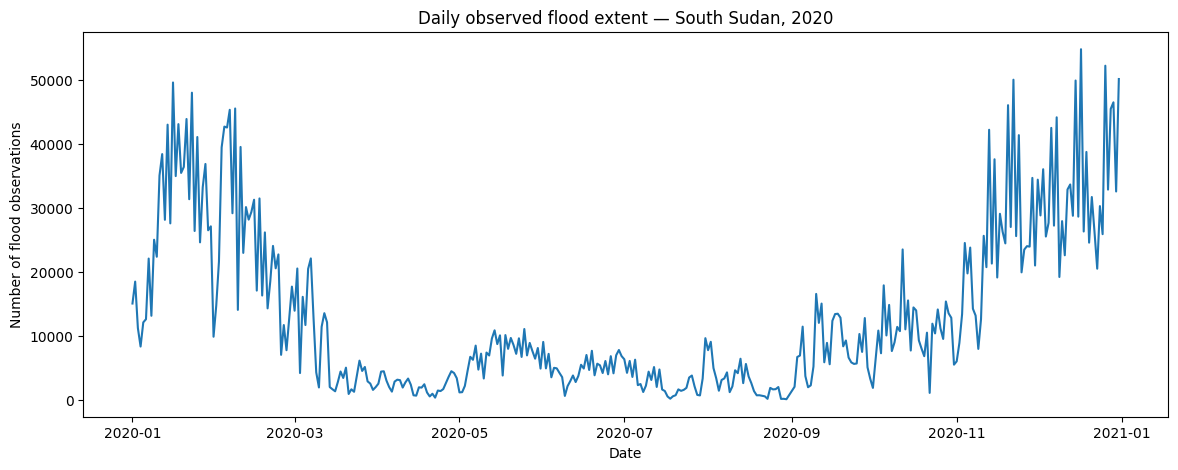

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_flood["date"],
    daily_flood["flood_pixels"]
)

plt.title("Daily observed flood extent — South Sudan, 2020")
plt.xlabel("Date")
plt.ylabel("Number of flood observations")

plt.show()

In [21]:
daily_flood_type = (
    flood_2020
    .groupby(["date", "flood_type_label"])
    .size()
    .reset_index(name="flood_pixels")
)

daily_flood_type.head()

,date,flood_type_label,flood_pixels
0,2020-01-01,Recurring,6836
1,2020-01-01,Unusual,8174
2,2020-01-02,Recurring,6890
3,2020-01-02,Unusual,11549
4,2020-01-03,Recurring,3745


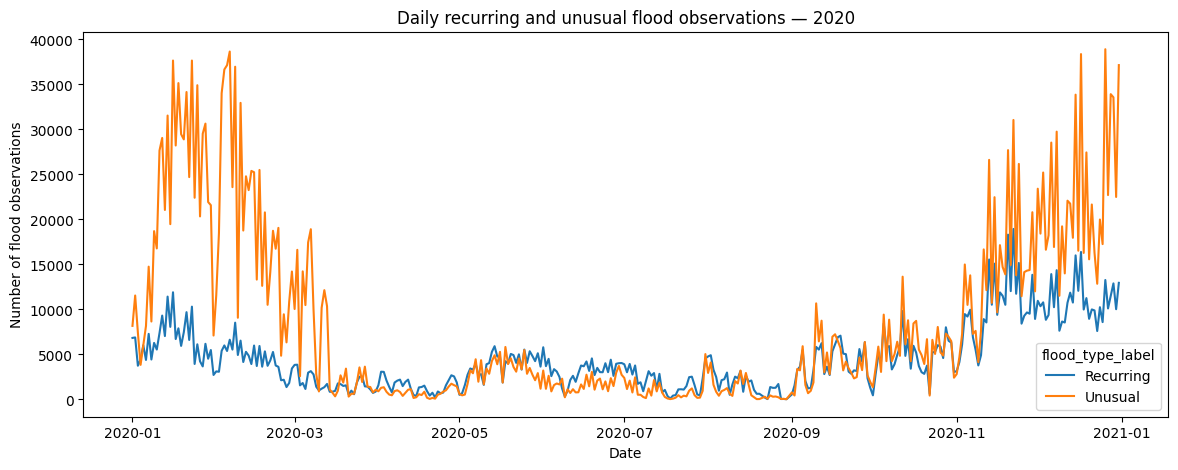

In [22]:
import seaborn as sns

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_flood_type,
    x="date",
    y="flood_pixels",
    hue="flood_type_label"
)

plt.title("Daily recurring and unusual flood observations — 2020")
plt.xlabel("Date")
plt.ylabel("Number of flood observations")

plt.show()

In [23]:
spatial_flood = (
    flood_2020
    .groupby(["lat", "lon"])
    .size()
    .reset_index(name="flood_days")
)

print("Unique flood locations:", len(spatial_flood))

spatial_flood["flood_days"].describe()

Unique flood locations: 291002


count    291002.000000
mean         16.374609
std          29.460950
min           1.000000
25%           1.000000
50%           4.000000
75%          18.000000
max         266.000000
Name: flood_days, dtype: float64

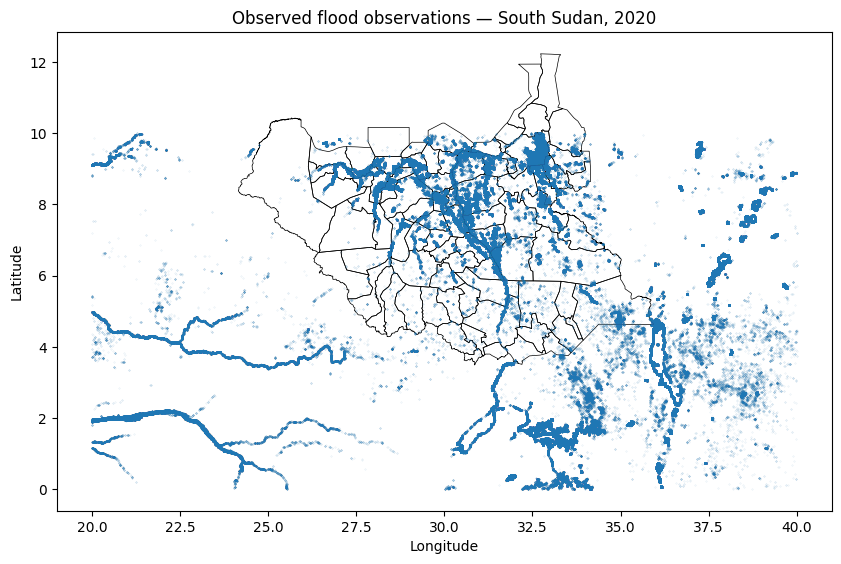

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

admin2.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
)

ax.scatter(
    flood_2020["lon"],
    flood_2020["lat"],
    s=0.05,
    alpha=0.2
)

ax.set_title("Observed flood observations — South Sudan, 2020")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [25]:
flood_gdf = gpd.GeoDataFrame(
    flood_2020,
    geometry=gpd.points_from_xy(
        flood_2020["lon"],
        flood_2020["lat"]
    ),
    crs="EPSG:4326"
)

print(flood_gdf.crs)

EPSG:4326


In [26]:
flood_admin2 = gpd.sjoin(
    flood_gdf,
    admin2,
    how="left",
    predicate="within"
)

print(flood_admin2.shape)

(4765044, 34)


In [27]:
print(
    flood_admin2["adm2_name"].isna().sum(),
    "flood observations were not assigned to an admin2 area."
)

2278849 flood observations were not assigned to an admin2 area.


In [28]:
flood_by_area = (
    flood_admin2
    .groupby("adm2_name")
    .agg(
        flood_observations=("date", "size"),
        flood_days=("date", "nunique")
    )
    .reset_index()
)

flood_by_area.head()

,adm2_name,flood_observations,flood_days
0,Abiemnhom,90,23
1,Abyei Region,35,14
2,Akobo,50202,117
3,Aweil Centre,7964,65
4,Aweil East,45164,96


In [29]:
flood_by_area.sort_values(
    "flood_observations",
    ascending=False
).head(10)

,adm2_name,flood_observations,flood_days
10,Baliet,1157880,204
42,Mayom,191248,191
64,Tonj North,131596,190
20,Gogrial West,107835,101
19,Gogrial East,96352,167
35,Luakpiny/Nasir,74462,185
9,Ayod,71320,253
68,Twic East,50724,242
2,Akobo,50202,117
11,Bor South,47622,243


In [30]:
admin2_flood = admin2.merge(
    flood_by_area,
    on="adm2_name",
    how="left"
)

admin2_flood["flood_observations"] = (
    admin2_flood["flood_observations"].fillna(0)
)

admin2_flood["flood_days"] = (
    admin2_flood["flood_days"].fillna(0)
)

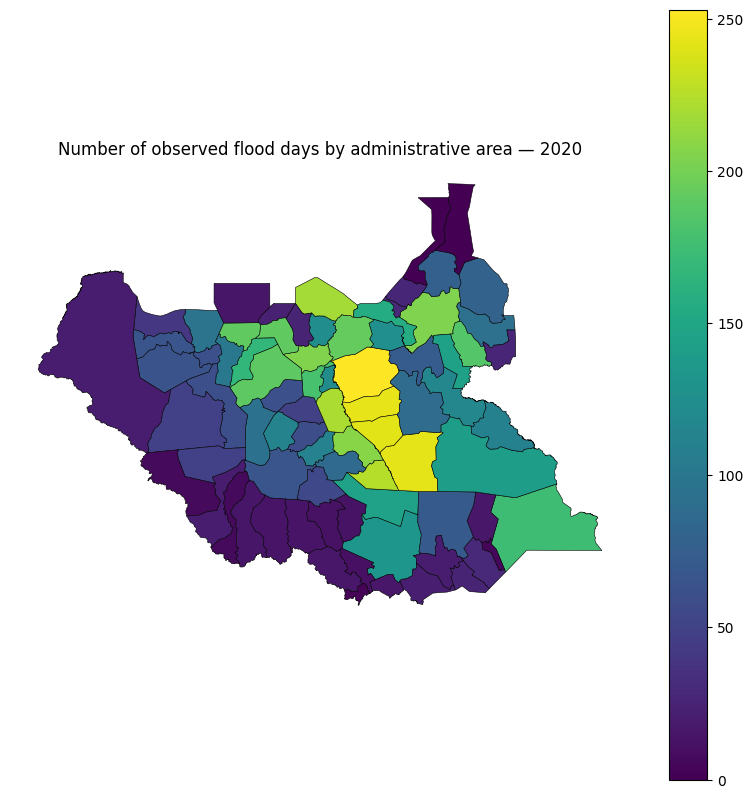

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

admin2_flood.plot(
    column="flood_days",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Number of observed flood days by administrative area — 2020")
ax.axis("off")

plt.show()

In [32]:
south_sudan_boundary = admin1.union_all()

print(south_sudan_boundary)

POLYGON ((35.01177841900011 6.002409248000049, 35.009933545000024 5.999054873000091, 35.01043667000016 5.993687873000113, 35.007178025000144 5.991656739000121, 35.003728045000116 5.991390248000187, 35.001993174 5.989539697000055, 35.00121229500019 5.988706749000073, 34.99982632400014 5.987320778000083, 34.99852879499997 5.986023247999981, 34.99852879499997 5.979985374000137, 34.99741347800017 5.978214019, 34.99567754500015 5.975456998000084, 34.99455460700017 5.971606824, 34.99332954400012 5.967406499, 34.992679752000186 5.961280410000029, 34.992316606000145 5.957856744000082, 34.99215542000013 5.956337124000129, 34.99251821000013 5.952419170000098, 34.99299404500016 5.947280374, 34.993696149000186 5.946110008000176, 34.99482258900014 5.944232843, 34.99651617000018 5.941410249000057, 35.00054142000016 5.938391374000105, 35.00205079500006 5.93486937300014, 35.00139777700008 5.930060698999966, 35.001204287 5.928636775000143, 35.0002059200001 5.921284124000067, 34.99974835699999 5.9147296

In [33]:
flood_gdf_ss = flood_gdf[
    flood_gdf.geometry.within(south_sudan_boundary)
].copy()

print("Original observations:", len(flood_gdf))
print("South Sudan observations:", len(flood_gdf_ss))
print(
    "Percentage retained:",
    len(flood_gdf_ss) / len(flood_gdf) * 100
)

Original observations: 4765044
South Sudan observations: 2486160
Percentage retained: 52.174964176616214


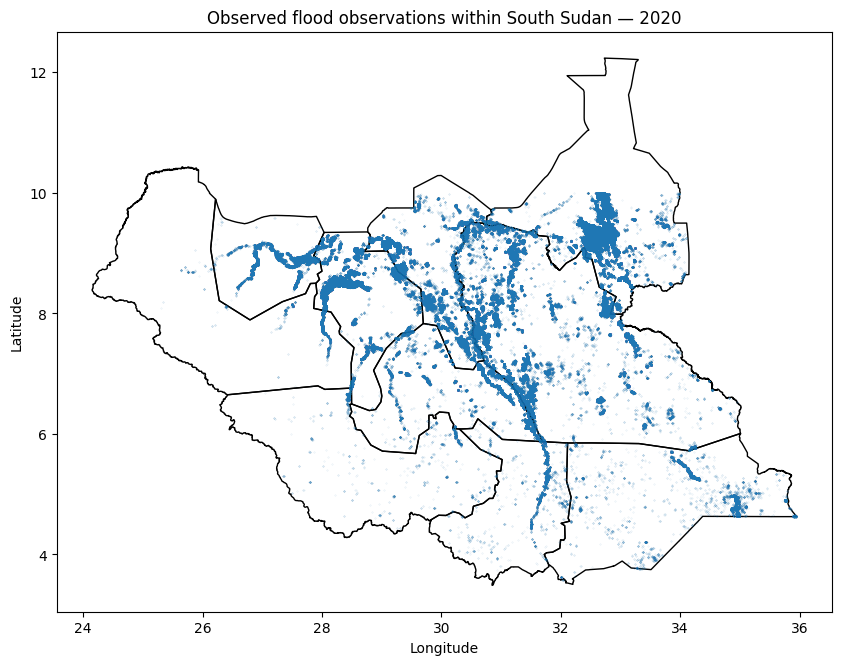

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

admin1.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.scatter(
    flood_gdf_ss["lon"],
    flood_gdf_ss["lat"],
    s=0.05,
    alpha=0.2
)

ax.set_title("Observed flood observations within South Sudan — 2020")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [35]:
flood_admin2 = gpd.sjoin(
    flood_gdf_ss,
    admin2,
    how="left",
    predicate="within"
)

print(flood_admin2.shape)

(2486160, 34)


In [36]:
print(
    "Unassigned observations:",
    flood_admin2["adm2_name"].isna().sum()
)

Unassigned observations: 0


In [37]:
flood_by_area = (
    flood_admin2
    .groupby("adm2_name")
    .agg(
        flood_observations=("date", "size"),
        flood_days=("date", "nunique")
    )
    .reset_index()
)

flood_by_area.sort_values(
    "flood_days",
    ascending=False
).head(10)

,adm2_name,flood_observations,flood_days
8,Ayod,71320,253
14,Duk,35449,244
10,Bor South,47622,243
67,Twic East,50724,242
7,Awerial,23759,225
50,Panyijiar,37038,221
52,Pariang,9724,219
74,Yirol East,39329,208
29,Koch,28179,205
9,Baliet,1157880,204


In [38]:
flood_by_area = (
    flood_admin2
    .groupby("adm2_name")
    .agg(
        flood_observations=("date", "size"),
        flood_days=("date", "nunique"),
        unusual_observations=("flood_type", lambda x: (x == 1).sum()),
        recurring_observations=("flood_type", lambda x: (x == 0).sum())
    )
    .reset_index()
)

flood_by_area["unusual_fraction"] = (
    flood_by_area["unusual_observations"]
    / flood_by_area["flood_observations"]
)

flood_by_area.sort_values(
    "flood_days",
    ascending=False
).head(15)

,adm2_name,flood_observations,flood_days,unusual_observations,recurring_observations,unusual_fraction
8,Ayod,71320,253,47803,23517,0.670261
14,Duk,35449,244,9757,25692,0.275240
10,Bor South,47622,243,35614,12008,0.747848
67,Twic East,50724,242,42924,7800,0.846227
7,Awerial,23759,225,11224,12535,0.472410
50,Panyijiar,37038,221,33549,3489,0.905799
52,Pariang,9724,219,6184,3540,0.635952
74,Yirol East,39329,208,34855,4474,0.886242
29,Koch,28179,205,12887,15292,0.457326
9,Baliet,1157880,204,1137862,20018,0.982712


In [39]:
daily_area_flood = (
    flood_admin2
    .groupby(["adm2_name", "date"])
    .size()
    .reset_index(name="daily_flood_extent")
)

flood_extent_features = (
    daily_area_flood
    .groupby("adm2_name")
    .agg(
        mean_daily_flood_extent=("daily_flood_extent", "mean"),
        max_daily_flood_extent=("daily_flood_extent", "max")
    )
    .reset_index()
)

flood_by_area = flood_by_area.merge(
    flood_extent_features,
    on="adm2_name",
    how="left"
)

flood_by_area.sort_values(
    "max_daily_flood_extent",
    ascending=False
).head(15)

,adm2_name,flood_observations,flood_days,unusual_observations,recurring_observations,unusual_fraction,mean_daily_flood_extent,max_daily_flood_extent
9,Baliet,1157880,204,1137862,20018,0.982712,5675.882353,29292
19,Gogrial West,107835,101,71581,36254,0.663801,1067.673267,5959
41,Mayom,191248,191,153567,37681,0.802973,1001.298429,4773
3,Aweil East,45164,96,16445,28719,0.364117,470.458333,4753
40,Mayendit,25627,179,24018,1609,0.937215,143.167598,4464
63,Tonj North,131596,190,23367,108229,0.177566,692.610526,4382
18,Gogrial East,96352,167,67292,29060,0.698398,576.958084,4049
1,Akobo,50202,117,48161,2041,0.959344,429.076923,3742
12,Canal/Pigi,26773,125,26677,96,0.996414,214.184000,2814
8,Ayod,71320,253,47803,23517,0.670261,281.897233,2642


In [40]:
flood_by_area.describe()

,flood_observations,flood_days,unusual_observations,recurring_observations,unusual_fraction,mean_daily_flood_extent,max_daily_flood_extent
count,7.600000e+01,76.000000,7.600000e+01,76.000000,76.000000,76.000000,76.000000
mean,3.271263e+04,94.960526,2.704822e+04,5664.407895,0.848332,193.482047,1320.407895
std,1.348880e+05,75.220643,1.311757e+05,14846.309769,0.217080,668.708834,3529.384884
min,4.000000e+00,2.000000,4.000000e+00,0.000000,0.177566,2.000000,3.000000
25%,1.955000e+02,25.000000,1.917500e+02,0.000000,0.762684,9.715455,56.750000
50%,3.639500e+03,75.000000,3.361500e+03,73.500000,0.951713,44.221075,300.500000
75%,2.250950e+04,148.500000,1.236200e+04,2648.250000,1.000000,143.696395,1401.750000
max,1.157880e+06,253.000000,1.137862e+06,108229.000000,1.000000,5675.882353,29292.000000


In [41]:
flood_by_area.sort_values(
    "flood_days",
    ascending=False
).head(10)

,adm2_name,flood_observations,flood_days,unusual_observations,recurring_observations,unusual_fraction,mean_daily_flood_extent,max_daily_flood_extent
8,Ayod,71320,253,47803,23517,0.670261,281.897233,2642
14,Duk,35449,244,9757,25692,0.275240,145.282787,633
10,Bor South,47622,243,35614,12008,0.747848,195.975309,1647
67,Twic East,50724,242,42924,7800,0.846227,209.603306,1950
7,Awerial,23759,225,11224,12535,0.472410,105.595556,793
50,Panyijiar,37038,221,33549,3489,0.905799,167.592760,1483
52,Pariang,9724,219,6184,3540,0.635952,44.401826,605
74,Yirol East,39329,208,34855,4474,0.886242,189.081731,2635
29,Koch,28179,205,12887,15292,0.457326,137.458537,849
9,Baliet,1157880,204,1137862,20018,0.982712,5675.882353,29292


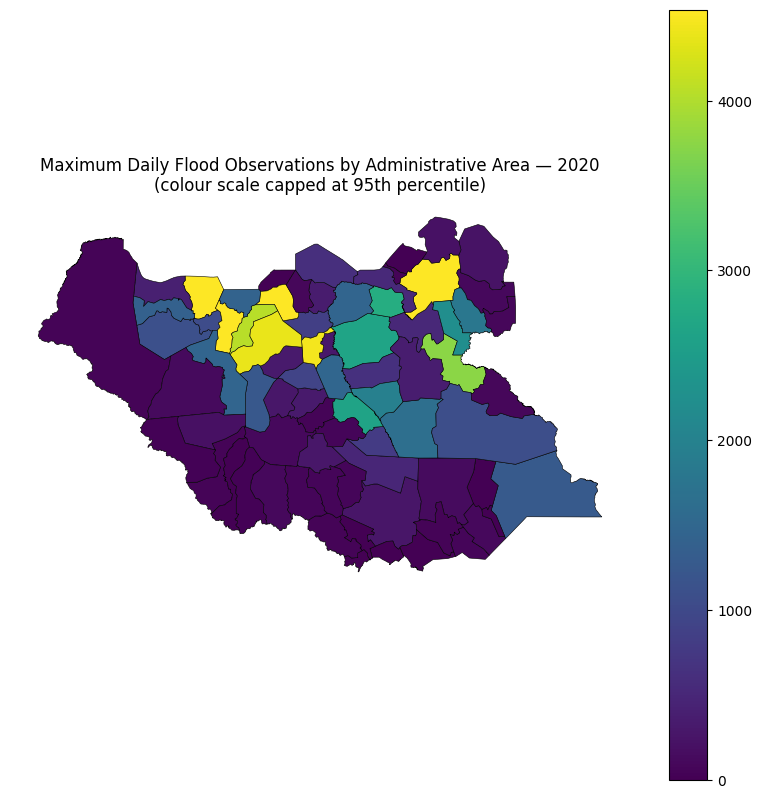

In [53]:
import numpy as np

# Add the updated flood metrics to the administrative boundaries
admin2_flood = admin2.merge(
    flood_by_area,
    on="adm2_name",
    how="left"
)

# Cap the colour scale at the 95th percentile
vmax = admin2_flood["max_daily_flood_extent"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 10))

admin2_flood.plot(
    column="max_daily_flood_extent",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    vmin=0,
    vmax=vmax
)

ax.set_title(
    "Maximum Daily Flood Observations by Administrative Area — 2020\n"
    "(colour scale capped at 95th percentile)"
)
ax.axis("off")

plt.show()

In [45]:
flood_by_area[
    [
        "flood_days",
        "flood_observations",
        "mean_daily_flood_extent",
        "max_daily_flood_extent",
        "unusual_fraction"
    ]
].describe()

,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent,unusual_fraction
count,76.000000,7.600000e+01,76.000000,76.000000,76.000000
mean,94.960526,3.271263e+04,193.482047,1320.407895,0.848332
std,75.220643,1.348880e+05,668.708834,3529.384884,0.217080
min,2.000000,4.000000e+00,2.000000,3.000000,0.177566
25%,25.000000,1.955000e+02,9.715455,56.750000,0.762684
50%,75.000000,3.639500e+03,44.221075,300.500000,0.951713
75%,148.500000,2.250950e+04,143.696395,1401.750000,1.000000
max,253.000000,1.157880e+06,5675.882353,29292.000000,1.000000


In [46]:
flood_by_area.sort_values(
    "max_daily_flood_extent",
    ascending=False
)[
    [
        "adm2_name",
        "flood_days",
        "flood_observations",
        "mean_daily_flood_extent",
        "max_daily_flood_extent"
    ]
].head(15)

,adm2_name,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent
9,Baliet,204,1157880,5675.882353,29292
19,Gogrial West,101,107835,1067.673267,5959
41,Mayom,191,191248,1001.298429,4773
3,Aweil East,96,45164,470.458333,4753
40,Mayendit,179,25627,143.167598,4464
63,Tonj North,190,131596,692.610526,4382
18,Gogrial East,167,96352,576.958084,4049
1,Akobo,117,50202,429.076923,3742
12,Canal/Pigi,125,26773,214.184000,2814
8,Ayod,253,71320,281.897233,2642


In [47]:
areas_with_floods = set(flood_by_area["adm2_name"])

areas_without_floods = admin2[
    ~admin2["adm2_name"].isin(areas_with_floods)
][["adm2_name"]]

areas_without_floods

,adm2_name
54,Manyo
57,Renk
65,Abyei Region


In [48]:
flood_by_area["flood_day_fraction"] = (
    flood_by_area["flood_days"] / 366
)

flood_by_area[
    ["adm2_name", "flood_days", "flood_day_fraction"]
].sort_values(
    "flood_day_fraction",
    ascending=False
).head(15)

,adm2_name,flood_days,flood_day_fraction
8,Ayod,253,0.691257
14,Duk,244,0.666667
10,Bor South,243,0.663934
67,Twic East,242,0.661202
7,Awerial,225,0.614754
50,Panyijiar,221,0.603825
52,Pariang,219,0.598361
74,Yirol East,208,0.568306
29,Koch,205,0.560109
9,Baliet,204,0.557377


In [49]:
admin2_area = admin2.to_crs("EPSG:6933").copy()

admin2_area["area_km2"] = (
    admin2_area.geometry.area / 1_000_000
)

admin2_area[
    ["adm2_name", "area_km2"]
].head()

,adm2_name,area_km2
0,Juba,18366.514881
1,Kajo-keji,2516.104546
2,Lainya,3498.916146
3,Morobo,1308.941909
4,Terekeka,10672.129966


In [50]:
flood_by_area = flood_by_area.merge(
    admin2_area[["adm2_name", "area_km2"]],
    on="adm2_name",
    how="left"
)

In [51]:
duplicates = flood_gdf_ss.duplicated(
    subset=["date", "lat", "lon"]
).sum()

print("Duplicate date/lat/lon observations:", duplicates)

Duplicate date/lat/lon observations: 0


In [52]:
pixel_area_km2 = 0.232 * 0.232

flood_by_area["mean_flood_area_km2"] = (
    flood_by_area["mean_daily_flood_extent"]
    * pixel_area_km2
)

flood_by_area["max_flood_area_km2"] = (
    flood_by_area["max_daily_flood_extent"]
    * pixel_area_km2
)

flood_by_area["max_flood_fraction"] = (
    flood_by_area["max_flood_area_km2"]
    / flood_by_area["area_km2"]
)

flood_by_area[
    [
        "adm2_name",
        "area_km2",
        "flood_days",
        "max_flood_area_km2",
        "max_flood_fraction"
    ]
].sort_values(
    "max_flood_fraction",
    ascending=False
).head(15)

,adm2_name,area_km2,flood_days,max_flood_area_km2,max_flood_fraction
9,Baliet,11675.847179,204,1576.612608,0.135032
40,Mayendit,3061.320976,179,240.270336,0.078486
19,Gogrial West,4401.062593,101,320.737216,0.072877
41,Mayom,4260.417527,191,256.901952,0.060300
18,Gogrial East,4424.801909,167,217.933376,0.049253
3,Aweil East,6367.533884,96,255.825472,0.040177
12,Canal/Pigi,4438.721625,125,151.460736,0.034123
5,Aweil South,1976.882858,62,55.600192,0.028125
74,Yirol East,5568.582837,208,141.826240,0.025469
68,Ulang,4833.588756,145,119.435456,0.024709


In [54]:
flood_features = flood_by_area[
    [
        "adm2_name",
        "flood_days",
        "flood_observations",
        "mean_daily_flood_extent",
        "max_daily_flood_extent",
        "unusual_fraction"
    ]
].copy()

flood_features.head()

,adm2_name,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent,unusual_fraction
0,Abiemnhom,23,90,3.913043,11,1.000000
1,Akobo,117,50202,429.076923,3742,0.959344
2,Aweil Centre,65,7964,122.523077,1099,0.830487
3,Aweil East,96,45164,470.458333,4753,0.364117
4,Aweil North,40,3440,86.000000,399,0.892151


In [55]:
flood_features.describe()

,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent,unusual_fraction
count,76.000000,7.600000e+01,76.000000,76.000000,76.000000
mean,94.960526,3.271263e+04,193.482047,1320.407895,0.848332
std,75.220643,1.348880e+05,668.708834,3529.384884,0.217080
min,2.000000,4.000000e+00,2.000000,3.000000,0.177566
25%,25.000000,1.955000e+02,9.715455,56.750000,0.762684
50%,75.000000,3.639500e+03,44.221075,300.500000,0.951713
75%,148.500000,2.250950e+04,143.696395,1401.750000,1.000000
max,253.000000,1.157880e+06,5675.882353,29292.000000,1.000000


In [56]:
# Add administrative area size
flood_features = flood_features.merge(
    admin2[["adm2_name", "area_sqkm"]],
    on="adm2_name",
    how="left"
)

# Normalize flood activity by administrative area size
flood_features["flood_observations_per_km2"] = (
    flood_features["flood_observations"]
    / flood_features["area_sqkm"]
)

flood_features["mean_daily_flood_observations_per_km2"] = (
    flood_features["mean_daily_flood_extent"]
    / flood_features["area_sqkm"]
)

flood_features["max_daily_flood_observations_per_km2"] = (
    flood_features["max_daily_flood_extent"]
    / flood_features["area_sqkm"]
)

flood_features.head()

,adm2_name,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent,unusual_fraction,area_sqkm,flood_observations_per_km2,mean_daily_flood_observations_per_km2,max_daily_flood_observations_per_km2
0,Abiemnhom,23,90,3.913043,11,1.000000,2407.827056,0.037378,0.001625,0.004568
1,Akobo,117,50202,429.076923,3742,0.959344,9024.067509,5.563123,0.047548,0.414669
2,Aweil Centre,65,7964,122.523077,1099,0.830487,11156.747654,0.713828,0.010982,0.098505
3,Aweil East,96,45164,470.458333,4753,0.364117,6367.533884,7.092856,0.073884,0.746443
4,Aweil North,40,3440,86.000000,399,0.892151,6342.814562,0.542346,0.013559,0.062906


In [57]:
flood_features[
    [
        "area_sqkm",
        "flood_observations_per_km2",
        "mean_daily_flood_observations_per_km2",
        "max_daily_flood_observations_per_km2"
    ]
].describe()

,area_sqkm,flood_observations_per_km2,mean_daily_flood_observations_per_km2,max_daily_flood_observations_per_km2
count,76.000000,76.000000,76.000000,76.000000
mean,8101.209760,4.409092,0.028384,0.204677
std,8330.832619,12.880616,0.068693,0.400589
min,754.680410,0.003056,0.000174,0.000774
25%,4362.545078,0.052066,0.001651,0.008933
50%,5785.951522,0.573291,0.004880,0.045965
75%,9067.254755,5.173095,0.023608,0.193939
max,62010.568725,99.168821,0.486122,2.508769


In [58]:
flood_features.sort_values(
    "max_daily_flood_observations_per_km2",
    ascending=False
)[
    [
        "adm2_name",
        "area_sqkm",
        "flood_days",
        "max_daily_flood_extent",
        "max_daily_flood_observations_per_km2"
    ]
].head(15)

,adm2_name,area_sqkm,flood_days,max_daily_flood_extent,max_daily_flood_observations_per_km2
9,Baliet,11675.847179,204,29292,2.508769
40,Mayendit,3061.320976,179,4464,1.458194
19,Gogrial West,4401.062593,101,5959,1.353991
41,Mayom,4260.417527,191,4773,1.120313
18,Gogrial East,4424.801909,167,4049,0.915069
3,Aweil East,6367.533884,96,4753,0.746443
12,Canal/Pigi,4438.721625,125,2814,0.633966
5,Aweil South,1976.882858,62,1033,0.522540
74,Yirol East,5568.582837,208,2635,0.473190
68,Ulang,4833.588756,145,2219,0.459079


In [59]:
flood_features.sort_values(
    "flood_days",
    ascending=False
)[
    [
        "adm2_name",
        "area_sqkm",
        "flood_days",
        "flood_observations",
        "unusual_fraction"
    ]
].head(15)

,adm2_name,area_sqkm,flood_days,flood_observations,unusual_fraction
8,Ayod,13449.146531,253,71320,0.670261
14,Duk,6885.076907,244,35449,0.275240
10,Bor South,13962.835622,243,47622,0.747848
67,Twic East,5943.900214,242,50724,0.846227
7,Awerial,4528.660810,225,23759,0.472410
50,Panyijiar,5324.973175,221,37038,0.905799
52,Pariang,8978.794299,219,9724,0.635952
74,Yirol East,5568.582837,208,39329,0.886242
29,Koch,4396.587596,205,28179,0.457326
9,Baliet,11675.847179,204,1157880,0.982712


In [60]:
import rasterio

worldcover_dir = Path("../raw_data/worldcover")

worldcover_files = sorted(worldcover_dir.glob("*.tif"))

print("Number of WorldCover tiles:", len(worldcover_files))
print("\nFirst few files:")
for path in worldcover_files[:5]:
    print(path.name)

Number of WorldCover tiles: 15

First few files:
ESA_WorldCover_10m_2021_v200_N03E024_Map.tif
ESA_WorldCover_10m_2021_v200_N03E027_Map.tif
ESA_WorldCover_10m_2021_v200_N03E030_Map.tif
ESA_WorldCover_10m_2021_v200_N03E033_Map.tif
ESA_WorldCover_10m_2021_v200_N06E021_Map.tif


In [61]:
for path in worldcover_files:
    with rasterio.open(path) as src:
        print(
            path.name,
            "| CRS:", src.crs,
            "| bounds:", src.bounds
        )

ESA_WorldCover_10m_2021_v200_N03E024_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=24.0, bottom=3.0, right=27.0, top=6.0)
ESA_WorldCover_10m_2021_v200_N03E027_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=27.0, bottom=3.0, right=30.0, top=6.0)
ESA_WorldCover_10m_2021_v200_N03E030_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=30.0, bottom=3.0, right=33.0, top=6.0)
ESA_WorldCover_10m_2021_v200_N03E033_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=33.0, bottom=3.0, right=36.0, top=6.0)
ESA_WorldCover_10m_2021_v200_N06E021_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=21.0, bottom=6.0, right=24.0, top=9.0)
ESA_WorldCover_10m_2021_v200_N06E024_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=24.0, bottom=6.0, right=27.0, top=9.0)
ESA_WorldCover_10m_2021_v200_N06E027_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=27.0, bottom=6.0, right=30.0, top=9.0)
ESA_WorldCover_10m_2021_v200_N06E030_Map.tif | CRS: EPSG:4326 | bounds: BoundingBox(left=30.0, bottom=6.

In [62]:
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
from shapely.geometry import box
from collections import Counter

# Select one administrative area for testing
test_area = admin2[admin2["adm2_name"] == "Ayod"].iloc[0]

class_counts = Counter()
total_valid_pixels = 0

for path in worldcover_files:
    with rasterio.open(path) as src:

        # Check whether the administrative area intersects this tile
        tile_box = box(*src.bounds)

        if not test_area.geometry.intersects(tile_box):
            continue

        # Get the part of the geometry inside the tile
        geometry = test_area.geometry.intersection(tile_box)

        # Find the raster window covering the geometry
        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )

        # Read only that part of the raster
        data = src.read(1, window=window)

        # Get the transform for the window
        window_transform = src.window_transform(window)

        # Create a mask for pixels inside the administrative area
        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )

        # Keep pixels inside the area and exclude NoData
        values = data[mask]
        values = values[values != 0]

        class_counts.update(values.tolist())
        total_valid_pixels += len(values)

print("Administrative area:", test_area["adm2_name"])
print("Valid WorldCover pixels:", total_valid_pixels)
print("\nClass counts:")
print(class_counts)

Administrative area: Ayod
Valid WorldCover pixels: 158956887

Class counts:
Counter({90: 71913128, 30: 59052181, 10: 25164957, 20: 1492946, 80: 1307269, 60: 24430, 50: 1976})


In [63]:
worldcover_classes = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow / ice",
    80: "Permanent water",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss / lichen"
}

ayod_landcover = []

for class_code, class_name in worldcover_classes.items():
    count = class_counts.get(class_code, 0)

    ayod_landcover.append({
        "class_code": class_code,
        "class_name": class_name,
        "pixel_count": count,
        "percentage": 100 * count / total_valid_pixels
    })

ayod_landcover = pd.DataFrame(ayod_landcover)

ayod_landcover

,class_code,class_name,pixel_count,percentage
0,10,Tree cover,25164957,15.831310
1,20,Shrubland,1492946,0.939214
2,30,Grassland,59052181,37.149810
3,40,Cropland,0,0.000000
4,50,Built-up,1976,0.001243
5,60,Bare / sparse vegetation,24430,0.015369
6,70,Snow / ice,0,0.000000
7,80,Permanent water,1307269,0.822405
8,90,Herbaceous wetland,71913128,45.240649
9,95,Mangroves,0,0.000000


In [64]:
ayod_landcover["percentage"].sum()

np.float64(100.0)

In [66]:
def calculate_worldcover_composition(area_geometry, worldcover_files):
    """
    Calculate WorldCover class composition for one administrative area.
    Returns pixel counts and percentages for each WorldCover class.
    """

    class_counts = Counter()
    total_valid_pixels = 0

    for path in worldcover_files:
        with rasterio.open(path) as src:

            tile_box = box(*src.bounds)

            # Skip tiles that do not intersect the area
            if not area_geometry.intersects(tile_box):
                continue

            # Keep only the part of the area inside this tile
            geometry = area_geometry.intersection(tile_box)

            # Determine the raster window covering the geometry
            window = from_bounds(
                *geometry.bounds,
                transform=src.transform
            )

            # Read only the required part of the raster
            data = src.read(1, window=window)

            window_transform = src.window_transform(window)

            # Mask pixels outside the administrative area
            mask = geometry_mask(
                [geometry],
                transform=window_transform,
                invert=True,
                out_shape=data.shape
            )

            values = data[mask]

            # Remove NoData
            values = values[values != 0]

            class_counts.update(values.tolist())
            total_valid_pixels += len(values)

    # Convert counts to percentages
    results = {}

    for class_code, class_name in worldcover_classes.items():
        count = class_counts.get(class_code, 0)

        if total_valid_pixels > 0:
            percentage = 100 * count / total_valid_pixels
        else:
            percentage = np.nan

        results[class_code] = percentage

    return results

ayod_result = calculate_worldcover_composition(
    test_area.geometry,
    worldcover_files
)

ayod_result

{10: 15.83130965568041,
 20: 0.939214417302976,
 30: 37.14980968393021,
 40: 0.0,
 50: 0.0012431043645186634,
 60: 0.015368947178740358,
 70: 0.0,
 80: 0.8224047568319578,
 90: 45.24064943471119,
 95: 0.0,
 100: 0.0}

## Livelihood exposure features — cropland and rangeland

In [67]:
farmland_dir = Path("../raw_data/farmland")

crop_path = farmland_dir / "asap_mask_crop_v04.tif"
rangeland_path = farmland_dir / "asap_mask_rangeland_v04.tif"

print("Crop raster exists:", crop_path.exists())
print("Rangeland raster exists:", rangeland_path.exists())

Crop raster exists: True
Rangeland raster exists: True


In [68]:
with rasterio.open(crop_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

CRS: EPSG:4326
Resolution: (0.004464285715, 0.004464285715)
Width: 80640
Height: 29346
Bounds: BoundingBox(left=-180.004464285715, bottom=-56.00446430667502, right=179.99553577188502, top=75.004464285715)
NoData: None
Data type: uint8


In [69]:
with rasterio.open(crop_path) as src:
    # South Sudan approximate bounding box
    window = rasterio.windows.from_bounds(
        24, 3,
        36, 13,
        transform=src.transform
    )
    
    crop_sample = src.read(1, window=window)

print("Sample shape:", crop_sample.shape)
print("Minimum value:", crop_sample.min())
print("Maximum value:", crop_sample.max())

print("\nUnique values:")
print(sorted(set(crop_sample.flatten())))

Sample shape: (2240, 2688)
Minimum value: 0
Maximum value: 100

Unique values:
[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uin

In [70]:
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
import numpy as np

test_area = admin2[admin2["adm2_name"] == "Ayod"].iloc[0]

crop_values = []

with rasterio.open(crop_path) as src:
    tile_box = box(*src.bounds)

    if test_area.geometry.intersects(tile_box):
        geometry = test_area.geometry.intersection(tile_box)

        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )

        data = src.read(1, window=window)
        window_transform = src.window_transform(window)

        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )

        values = data[mask]

        crop_values = values.astype(float)

print("Administrative area:", test_area["adm2_name"])
print("Number of raster pixels:", len(crop_values))
print("Minimum crop percentage:", crop_values.min())
print("Maximum crop percentage:", crop_values.max())
print("Mean crop percentage:", crop_values.mean())

Administrative area: Ayod
Number of raster pixels: 55384
Minimum crop percentage: 0.0
Maximum crop percentage: 18.0
Mean crop percentage: 0.0014625162501805576


In [71]:
rangeland_values = []

with rasterio.open(rangeland_path) as src:
    tile_box = box(*src.bounds)

    if test_area.geometry.intersects(tile_box):
        geometry = test_area.geometry.intersection(tile_box)

        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )

        data = src.read(1, window=window)
        window_transform = src.window_transform(window)

        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )

        values = data[mask]

        rangeland_values = values.astype(float)

print("Administrative area:", test_area["adm2_name"])
print("Number of raster pixels:", len(rangeland_values))
print("Minimum rangeland percentage:", rangeland_values.min())
print("Maximum rangeland percentage:", rangeland_values.max())
print("Mean rangeland percentage:", rangeland_values.mean())

Administrative area: Ayod
Number of raster pixels: 55384
Minimum rangeland percentage: 0.0
Maximum rangeland percentage: 100.0
Mean rangeland percentage: 37.60672757475083


In [72]:
print("Crop percentage distribution in Ayod:")
print(
    pd.Series(crop_values)
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)

print("\nNumber of pixels with any crop coverage:", np.sum(crop_values > 0))
print(
    "Percentage of pixels with any crop coverage:",
    100 * np.mean(crop_values > 0)
)

Crop percentage distribution in Ayod:
count    55384.000000
mean         0.001463
std          0.125973
min          0.000000
50%          0.000000
90%          0.000000
95%          0.000000
99%          0.000000
max         18.000000
dtype: float64

Number of pixels with any crop coverage: 22
Percentage of pixels with any crop coverage: 0.03972266358515095


In [73]:
def calculate_farmland_features(area_geometry, raster_path):
    """
    Calculate farmland coverage statistics for one administrative area.

    Returns:
        mean_pct: mean percentage coverage across pixels
        max_pct: maximum percentage coverage in any pixel
        pixels_with_any_pct: percentage of pixels with >0 coverage
    """
    
    with rasterio.open(raster_path) as src:
        tile_box = box(*src.bounds)
        
        if not area_geometry.intersects(tile_box):
            return np.nan, np.nan, np.nan
        
        geometry = area_geometry.intersection(tile_box)
        
        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )
        
        data = src.read(1, window=window)
        window_transform = src.window_transform(window)
        
        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )
        
        values = data[mask].astype(float)
    
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    
    mean_pct = values.mean()
    max_pct = values.max()
    pixels_with_any_pct = 100 * np.mean(values > 0)
    
    return mean_pct, max_pct, pixels_with_any_pct

In [74]:
ayod_crop = calculate_farmland_features(
    test_area.geometry,
    crop_path
)

ayod_rangeland = calculate_farmland_features(
    test_area.geometry,
    rangeland_path
)

print("Ayod crop features:")
print(ayod_crop)

print("\nAyod rangeland features:")
print(ayod_rangeland)

Ayod crop features:
(np.float64(0.0014625162501805576), np.float64(18.0), np.float64(0.03972266358515095))

Ayod rangeland features:
(np.float64(37.60672757475083), np.float64(100.0), np.float64(62.456666185179834))


In [75]:
# Calculate cropland and rangeland features for all administrative areas

farmland_features = []

for _, area in admin2.iterrows():
    crop_mean, crop_max, crop_any = calculate_farmland_features(
        area.geometry,
        crop_path
    )

    rangeland_mean, rangeland_max, rangeland_any = calculate_farmland_features(
        area.geometry,
        rangeland_path
    )

    farmland_features.append({
        "adm2_name": area["adm2_name"],
        "crop_mean_pct": crop_mean,
        "crop_max_pct": crop_max,
        "crop_pixels_with_any_coverage_pct": crop_any,
        "rangeland_mean_pct": rangeland_mean,
        "rangeland_max_pct": rangeland_max,
        "rangeland_pixels_with_any_coverage_pct": rangeland_any
    })

farmland_features = pd.DataFrame(farmland_features)

print("Number of administrative areas:", len(farmland_features))
farmland_features.head()

Number of administrative areas: 79


,adm2_name,crop_mean_pct,crop_max_pct,crop_pixels_with_any_coverage_pct,rangeland_mean_pct,rangeland_max_pct,rangeland_pixels_with_any_coverage_pct
0,Juba,0.112515,70.0,2.394580,74.521137,100.0,98.565116
1,Kajo-keji,0.278129,40.0,7.595060,53.005640,100.0,99.153943
2,Lainya,0.434503,63.0,7.360548,41.101706,100.0,99.391864
3,Morobo,2.100318,80.0,24.883243,38.164581,95.0,99.364842
4,Terekeka,0.050525,51.0,1.320336,73.697444,100.0,94.739251


In [76]:
print(farmland_features.shape)

print("\nMissing values:")
print(farmland_features.isna().sum())

print("\nSummary statistics:")
print(
    farmland_features[
        [
            "crop_mean_pct",
            "crop_max_pct",
            "crop_pixels_with_any_coverage_pct",
            "rangeland_mean_pct",
            "rangeland_max_pct",
            "rangeland_pixels_with_any_coverage_pct"
        ]
    ].describe()
)

(79, 7)

Missing values:
adm2_name                                 0
crop_mean_pct                             0
crop_max_pct                              0
crop_pixels_with_any_coverage_pct         0
rangeland_mean_pct                        0
rangeland_max_pct                         0
rangeland_pixels_with_any_coverage_pct    0
dtype: int64

Summary statistics:
       crop_mean_pct  crop_max_pct  crop_pixels_with_any_coverage_pct  \
count      79.000000     79.000000                          79.000000   
mean        0.755955     45.354430                           5.222796   
std         1.994204     36.336758                           8.723851   
min         0.000000      0.000000                           0.000000   
25%         0.002045      9.000000                           0.113337   
50%         0.050525     43.000000                           0.894188   
75%         0.485112     79.500000                           6.452676   
max        14.975091    100.000000               

In [77]:
print("Highest mean crop coverage:")
display(
    farmland_features[
        ["adm2_name", "crop_mean_pct", "crop_pixels_with_any_coverage_pct"]
    ]
    .sort_values("crop_mean_pct", ascending=False)
    .head(10)
)

print("\nHighest mean rangeland coverage:")
display(
    farmland_features[
        ["adm2_name", "rangeland_mean_pct", "rangeland_pixels_with_any_coverage_pct"]
    ]
    .sort_values("rangeland_mean_pct", ascending=False)
    .head(10)
)

Highest mean crop coverage:


,adm2_name,crop_mean_pct,crop_pixels_with_any_coverage_pct
57,Renk,14.975091,25.742123
10,Kapoeta South,5.242313,36.428426
54,Manyo,4.500972,9.866149
7,Ikotos,4.438144,27.500697
60,Gogrial West,4.199978,38.606548
6,Budi,3.639758,22.609549
34,Aweil East,2.992353,26.445746
3,Morobo,2.100318,24.883243
71,Maridi,2.073915,5.603284
36,Aweil South,1.739985,21.971000



Highest mean rangeland coverage:


,adm2_name,rangeland_mean_pct,rangeland_pixels_with_any_coverage_pct
24,Uror,95.956662,99.918080
11,Lafon,90.883262,99.897757
16,Bor South,83.864867,92.466208
29,Rumbek North,82.256830,98.287407
51,Maban,81.879740,99.603426
21,Pibor,81.542606,98.181724
27,Rumbek Centre,81.057388,99.747187
47,Baliet,78.658491,98.934340
53,Malakal,77.596666,95.479320
56,Panyikang,75.749182,97.952121


## Livelihood exposure features — cattle

In [78]:
cattle_path = Path("../raw_data/farmland/geonode__cattle_gha.tif")

print("Cattle raster exists:", cattle_path.exists())

with rasterio.open(cattle_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Cattle raster exists: True
CRS: EPSG:4326
Resolution: (0.08333333333333331, 0.08333333333333333)
Width: 355
Height: 419
Bounds: BoundingBox(left=21.833333333333314, bottom=-11.749999999999993, right=51.41666666666664, top=23.16666666666667)
NoData: -1.7e+308
Data type: float64


In [79]:
with rasterio.open(cattle_path) as src:
    cattle_data = src.read(1)

# Remove NoData
valid_cattle = cattle_data[cattle_data != src.nodata]

print("Number of valid pixels:", len(valid_cattle))
print("Minimum value:", valid_cattle.min())
print("Maximum value:", valid_cattle.max())
print("Mean value:", valid_cattle.mean())
print("Median value:", np.median(valid_cattle))

print("\nPercentiles:")
print(
    np.percentile(
        valid_cattle,
        [0, 25, 50, 75, 90, 95, 99, 100]
    )
)

Number of valid pixels: 73307
Minimum value: 0.0
Maximum value: 84625.45009501623
Mean value: 2094.120834157292
Median value: 841.5483714702096

Percentiles:
[    0.           106.86730326   841.54837147  2419.19041325
  5784.13289214  8591.0948977  16263.87815145 84625.45009502]


In [80]:
print("First 20 unique values:")
print(np.unique(valid_cattle)[:20])

First 20 unique values:
[0.00000000e+00 3.70734124e-14 3.81353173e-14 5.56304321e-14
 7.40646626e-14 7.41468247e-14 7.41739095e-14 9.25808282e-14
 1.14405952e-13 1.48184403e-13 1.48401650e-13 1.67071755e-13
 2.40799654e-13 2.40888560e-13 2.96910229e-13 3.00337527e-13
 3.15008118e-13 5.00307010e-13 8.52688485e-13 9.64610722e-13]


In [81]:
with rasterio.open(cattle_path) as src:
    tile_box = box(*src.bounds)

    geometry = test_area.geometry.intersection(tile_box)

    window = from_bounds(
        *geometry.bounds,
        transform=src.transform
    )

    data = src.read(1, window=window)
    window_transform = src.window_transform(window)

    mask = geometry_mask(
        [geometry],
        transform=window_transform,
        invert=True,
        out_shape=data.shape
    )

    values = data[mask].astype(float)

    # Remove NoData
    values = values[values != src.nodata]

print("Ayod cattle pixels:", len(values))
print("Minimum:", values.min())
print("Maximum:", values.max())
print("Mean:", values.mean())
print("Median:", np.median(values))

Ayod cattle pixels: 161
Minimum: 393.33726802616417
Maximum: 2365.256926991624
Mean: 1286.0278254328891
Median: 1263.2709121314283


In [82]:
cattle_features = []

for _, area in admin2.iterrows():

    with rasterio.open(cattle_path) as src:
        tile_box = box(*src.bounds)

        if not area.geometry.intersects(tile_box):
            cattle_features.append({
                "adm2_name": area["adm2_name"],
                "cattle_exposure_mean": np.nan,
                "cattle_exposure_median": np.nan,
                "cattle_exposure_max": np.nan
            })
            continue

        geometry = area.geometry.intersection(tile_box)

        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )

        data = src.read(1, window=window)
        window_transform = src.window_transform(window)

        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )

        values = data[mask].astype(float)

        # Remove NoData
        values = values[values != src.nodata]

    if len(values) == 0:
        mean_value = np.nan
        median_value = np.nan
        max_value = np.nan
    else:
        mean_value = values.mean()
        median_value = np.median(values)
        max_value = values.max()

    cattle_features.append({
        "adm2_name": area["adm2_name"],
        "cattle_exposure_mean": mean_value,
        "cattle_exposure_median": median_value,
        "cattle_exposure_max": max_value
    })

cattle_features = pd.DataFrame(cattle_features)

print("Number of administrative areas:", len(cattle_features))
display(cattle_features.head())

Number of administrative areas: 79


,adm2_name,cattle_exposure_mean,cattle_exposure_median,cattle_exposure_max
0,Juba,1662.229181,1861.022860,4670.347219
1,Kajo-keji,2514.959222,2516.917579,4968.197822
2,Lainya,1577.107284,1580.476379,2403.642627
3,Morobo,3477.095151,3248.027071,6424.881933
4,Terekeka,1972.564521,2690.417686,4014.360689


In [83]:
print("Shape:", cattle_features.shape)

print("\nMissing values:")
print(cattle_features.isna().sum())

print("\nSummary statistics:")
print(
    cattle_features[
        [
            "cattle_exposure_mean",
            "cattle_exposure_median",
            "cattle_exposure_max"
        ]
    ].describe()
)

Shape: (79, 4)

Missing values:
adm2_name                 0
cattle_exposure_mean      0
cattle_exposure_median    0
cattle_exposure_max       0
dtype: int64

Summary statistics:
       cattle_exposure_mean  cattle_exposure_median  cattle_exposure_max
count             79.000000               79.000000            79.000000
mean            2173.249612             2178.795750          3731.392579
std             1430.217024             1481.753173          1949.050788
min              471.825991                0.000000           939.085710
25%             1107.144307             1069.115775          2075.256509
50%             1627.932525             1591.303846          3473.386947
75%             3111.722446             3079.266828          5050.516336
max             6695.378300             6868.474909          9543.940240


In [84]:
# Combine the area-level feature tables

area_features = admin2[
    ["adm2_name", "area_sqkm", "geometry"]
].copy()

area_features = area_features.merge(
    flood_features,
    on="adm2_name",
    how="left"
)

area_features = area_features.merge(
    farmland_features,
    on="adm2_name",
    how="left"
)

area_features = area_features.merge(
    cattle_features,
    on="adm2_name",
    how="left"
)

print("Shape:", area_features.shape)

print("\nColumns:")
print(area_features.columns.tolist())

display(area_features.head())

Shape: (79, 21)

Columns:
['adm2_name', 'area_sqkm_x', 'geometry', 'flood_days', 'flood_observations', 'mean_daily_flood_extent', 'max_daily_flood_extent', 'unusual_fraction', 'area_sqkm_y', 'flood_observations_per_km2', 'mean_daily_flood_observations_per_km2', 'max_daily_flood_observations_per_km2', 'crop_mean_pct', 'crop_max_pct', 'crop_pixels_with_any_coverage_pct', 'rangeland_mean_pct', 'rangeland_max_pct', 'rangeland_pixels_with_any_coverage_pct', 'cattle_exposure_mean', 'cattle_exposure_median', 'cattle_exposure_max']


,adm2_name,area_sqkm_x,geometry,flood_days,flood_observations,mean_daily_flood_extent,max_daily_flood_extent,unusual_fraction,area_sqkm_y,flood_observations_per_km2,...,max_daily_flood_observations_per_km2,crop_mean_pct,crop_max_pct,crop_pixels_with_any_coverage_pct,rangeland_mean_pct,rangeland_max_pct,rangeland_pixels_with_any_coverage_pct,cattle_exposure_mean,cattle_exposure_median,cattle_exposure_max
0,Juba,18366.514881,"POLYGON ((32.12034 5.13695, 32.1199 5.1385, 32...",133.0,4443.0,33.406015,263.0,0.764348,18366.514881,0.241908,...,0.014320,0.112515,70.0,2.394580,74.521137,100.0,98.565116,1662.229181,1861.022860,4670.347219
1,Kajo-keji,2516.104546,"POLYGON ((31.69216 3.95909, 31.69206 3.95919, ...",15.0,36.0,2.400000,8.0,0.722222,2516.104546,0.014308,...,0.003180,0.278129,40.0,7.595060,53.005640,100.0,99.153943,2514.959222,2516.917579,4968.197822
2,Lainya,3498.916146,"POLYGON ((31.17471 4.37282, 31.17503 4.37347, ...",10.0,67.0,6.700000,14.0,1.000000,3498.916146,0.019149,...,0.004001,0.434503,63.0,7.360548,41.101706,100.0,99.391864,1577.107284,1580.476379,2403.642627
3,Morobo,1308.941909,"POLYGON ((31.04738 3.81817, 31.04738 3.82137, ...",2.0,4.0,2.000000,3.0,1.000000,1308.941909,0.003056,...,0.002292,2.100318,80.0,24.883243,38.164581,95.0,99.364842,3477.095151,3248.027071,6424.881933
4,Terekeka,10672.129966,"POLYGON ((32.10548 5.49597, 32.10685 5.55038, ...",146.0,8855.0,60.650685,484.0,0.957538,10672.129966,0.829731,...,0.045352,0.050525,51.0,1.320336,73.697444,100.0,94.739251,1972.564521,2690.417686,4014.360689


In [85]:
print("Number of areas:", area_features["adm2_name"].nunique())

print("\nMissing values by column:")
print(area_features.isna().sum())

Number of areas: 79

Missing values by column:
adm2_name                                 0
area_sqkm_x                               0
geometry                                  0
flood_days                                3
flood_observations                        3
mean_daily_flood_extent                   3
max_daily_flood_extent                    3
unusual_fraction                          3
area_sqkm_y                               3
flood_observations_per_km2                3
mean_daily_flood_observations_per_km2     3
max_daily_flood_observations_per_km2      3
crop_mean_pct                             0
crop_max_pct                              0
crop_pixels_with_any_coverage_pct         0
rangeland_mean_pct                        0
rangeland_max_pct                         0
rangeland_pixels_with_any_coverage_pct    0
cattle_exposure_mean                      0
cattle_exposure_median                    0
cattle_exposure_max                       0
dtype: int64


In [86]:
missing_flood_areas = area_features[
    area_features["flood_days"].isna()
][
    ["adm2_name", "area_sqkm_x"]
]

display(missing_flood_areas)

,adm2_name,area_sqkm_x
54,Manyo,6679.031318
57,Renk,10024.098087
65,Abyei Region,10495.850579


In [87]:
print("Areas without flood features:")
print(missing_flood_areas["adm2_name"].tolist())

print("\nNumber of areas in flood_features:")
print(flood_features["adm2_name"].nunique())

print("\nFlood feature area names not matched:")
print(
    sorted(
        set(admin2["adm2_name"]) -
        set(flood_features["adm2_name"])
    )
)

Areas without flood features:
['Manyo', 'Renk', 'Abyei Region']

Number of areas in flood_features:
76

Flood feature area names not matched:
['Abyei Region', 'Manyo', 'Renk']


In [88]:
area_features = area_features.rename(
    columns={"area_sqkm_x": "area_sqkm"}
)

area_features = area_features.drop(
    columns=["area_sqkm_y"]
)

print("Shape:", area_features.shape)

print("\nColumns:")
print(area_features.columns.tolist())

print("\nMissing values:")
print(area_features.isna().sum())

Shape: (79, 20)

Columns:
['adm2_name', 'area_sqkm', 'geometry', 'flood_days', 'flood_observations', 'mean_daily_flood_extent', 'max_daily_flood_extent', 'unusual_fraction', 'flood_observations_per_km2', 'mean_daily_flood_observations_per_km2', 'max_daily_flood_observations_per_km2', 'crop_mean_pct', 'crop_max_pct', 'crop_pixels_with_any_coverage_pct', 'rangeland_mean_pct', 'rangeland_max_pct', 'rangeland_pixels_with_any_coverage_pct', 'cattle_exposure_mean', 'cattle_exposure_median', 'cattle_exposure_max']

Missing values:
adm2_name                                 0
area_sqkm                                 0
geometry                                  0
flood_days                                3
flood_observations                        3
mean_daily_flood_extent                   3
max_daily_flood_extent                    3
unusual_fraction                          3
flood_observations_per_km2                3
mean_daily_flood_observations_per_km2     3
max_daily_flood_observations_p

In [89]:
print(
    "Areas with flood observations:",
    area_features["flood_days"].notna().sum()
)

print(
    "Areas without flood observations:",
    area_features["flood_days"].isna().sum()
)

Areas with flood observations: 76
Areas without flood observations: 3


## WorldPop data exposure

In [90]:
worldpop_dir = Path("../raw_data/worldpop")
worldpop_2020_path = worldpop_dir / "ssd_pop_2020_CN_100m_R2025A_v1.tif"

print("WorldPop 2020 exists:", worldpop_2020_path.exists())

with rasterio.open(worldpop_2020_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

WorldPop 2020 exists: True
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Width: 14156
Height: 10496
Bounds: BoundingBox(left=24.152499183389995, bottom=3.490000322039986, right=35.94916580287, top=12.236666953719986)
NoData: -99999.0
Data type: float32


In [91]:
with rasterio.open(worldpop_2020_path) as src:
    tile_box = box(*src.bounds)

    geometry = test_area.geometry.intersection(tile_box)

    window = from_bounds(
        *geometry.bounds,
        transform=src.transform
    )

    data = src.read(1, window=window)
    window_transform = src.window_transform(window)

    mask = geometry_mask(
        [geometry],
        transform=window_transform,
        invert=True,
        out_shape=data.shape
    )

    values = data[mask].astype(float)

    # Remove NoData
    values = values[values != src.nodata]

print("Ayod valid population pixels:", len(values))
print("Minimum population per pixel:", values.min())
print("Maximum population per pixel:", values.max())
print("Mean population per pixel:", values.mean())
print("Total population:", values.sum())

Ayod valid population pixels: 18515
Minimum population per pixel: 0.0
Maximum population per pixel: 178.37318420410156
Mean population per pixel: 8.948266269256544
Total population: 165677.14997528493


In [92]:
population_features = []

with rasterio.open(worldpop_2020_path) as src:
    tile_box = box(*src.bounds)

    for _, area in admin2.iterrows():

        if not area.geometry.intersects(tile_box):
            population_features.append({
                "adm2_name": area["adm2_name"],
                "population_2020": np.nan
            })
            continue

        geometry = area.geometry.intersection(tile_box)

        window = from_bounds(
            *geometry.bounds,
            transform=src.transform
        )

        data = src.read(1, window=window)
        window_transform = src.window_transform(window)

        mask = geometry_mask(
            [geometry],
            transform=window_transform,
            invert=True,
            out_shape=data.shape
        )

        values = data[mask].astype(float)

        # Remove NoData
        values = values[values != src.nodata]

        if len(values) == 0:
            population = np.nan
        else:
            population = values.sum()

        population_features.append({
            "adm2_name": area["adm2_name"],
            "population_2020": population
        })

population_features = pd.DataFrame(population_features)

print("Number of administrative areas:", len(population_features))
display(population_features.head())

Number of administrative areas: 79


,adm2_name,population_2020
0,Juba,462333.673890
1,Kajo-keji,198533.672166
2,Lainya,99558.800309
3,Morobo,96715.308367
4,Terekeka,224591.283334


In [93]:
print("Shape:", population_features.shape)

print("\nMissing values:")
print(population_features.isna().sum())

print("\nPopulation summary:")
print(population_features["population_2020"].describe())

Shape: (79, 2)

Missing values:
adm2_name          0
population_2020    0
dtype: int64

Population summary:
count        79.000000
mean     133202.644013
std       78703.522218
min          29.310692
25%       70536.657960
50%      120813.332386
75%      165392.147842
max      462333.673890
Name: population_2020, dtype: float64


In [94]:
# Add population exposure to the master area feature table

area_features = area_features.merge(
    population_features,
    on="adm2_name",
    how="left"
)

print("Shape:", area_features.shape)

print("\nMissing values:")
print(
    area_features[
        ["adm2_name", "population_2020"]
    ].isna().sum()
)

display(
    area_features[
        ["adm2_name", "population_2020"]
    ].head()
)

Shape: (79, 21)

Missing values:
adm2_name          0
population_2020    0
dtype: int64


,adm2_name,population_2020
0,Juba,462333.673890
1,Kajo-keji,198533.672166
2,Lainya,99558.800309
3,Morobo,96715.308367
4,Terekeka,224591.283334


In [95]:
print("Most populated administrative areas:")
display(
    area_features[
        ["adm2_name", "population_2020"]
    ]
    .sort_values("population_2020", ascending=False)
    .head(10)
)

Most populated administrative areas:


,adm2_name,population_2020
0,Juba,462333.673890
34,Aweil East,291672.987566
16,Bor South,285320.365261
46,Rubkona,284793.150797
60,Gogrial West,282303.272461
68,Wau,274924.422844
5,Yei,249752.368623
50,Luakpiny/Nasir,244026.959015
66,Jur River,242406.738409
64,Twic,233090.214153


In [96]:
print(area_features.columns.tolist())

['adm2_name', 'area_sqkm', 'geometry', 'flood_days', 'flood_observations', 'mean_daily_flood_extent', 'max_daily_flood_extent', 'unusual_fraction', 'flood_observations_per_km2', 'mean_daily_flood_observations_per_km2', 'max_daily_flood_observations_per_km2', 'crop_mean_pct', 'crop_max_pct', 'crop_pixels_with_any_coverage_pct', 'rangeland_mean_pct', 'rangeland_max_pct', 'rangeland_pixels_with_any_coverage_pct', 'cattle_exposure_mean', 'cattle_exposure_median', 'cattle_exposure_max', 'population_2020']
